In [1]:
import pandas as pd
df_sentiment = pd.read_csv('fear_greed_index.csv')

In [2]:
df_sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [4]:
df_trader = pd.read_csv('historical_data.csv')

In [5]:
df_trader.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [10]:
df_sentiment.shape

(2644, 4)

In [11]:
df_trader.shape

(211224, 16)

In [12]:
df_sentiment.columns

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

In [13]:
df_trader.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')

## Part A - Data preparation

In [14]:
df_sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [15]:
df_trader.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [16]:
df_sentiment.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [20]:
df_sentiment.duplicated().sum()

np.int64(0)

In [18]:
df_trader.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [21]:
df_trader.duplicated().sum()

np.int64(0)

In [22]:
df_trader['Timestamp'] = pd.to_datetime(df_trader['Timestamp'], unit = 'ms')

In [24]:
df_trader["Timestamp"].head()

0   2024-10-27 03:33:20
1   2024-10-27 03:33:20
2   2024-10-27 03:33:20
3   2024-10-27 03:33:20
4   2024-10-27 03:33:20
Name: Timestamp, dtype: datetime64[ns]

In [25]:
df_trader['Date'] = df_trader['Timestamp'].dt.date

In [36]:
df_trader['Date']

0         2024-10-27
1         2024-10-27
2         2024-10-27
3         2024-10-27
4         2024-10-27
             ...    
211219    2025-06-15
211220    2025-06-15
211221    2025-06-15
211222    2025-06-15
211223    2025-06-15
Name: Date, Length: 211224, dtype: object

In [38]:
df_sentiment['date'].head()

0    2018-02-01
1    2018-02-02
2    2018-02-03
3    2018-02-04
4    2018-02-05
Name: date, dtype: object

In [39]:
df_trader["Date"].head()

0    2024-10-27
1    2024-10-27
2    2024-10-27
3    2024-10-27
4    2024-10-27
Name: Date, dtype: object

In [41]:
df_sentiment['date'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 2644 entries, 0 to 2643
Series name: date
Non-Null Count  Dtype 
--------------  ----- 
2644 non-null   object
dtypes: object(1)
memory usage: 20.8+ KB


In [43]:
df_trader['Date'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 211224 entries, 0 to 211223
Series name: Date
Non-Null Count   Dtype 
--------------   ----- 
211224 non-null  object
dtypes: object(1)
memory usage: 1.6+ MB


In [47]:
df_trader['Date'] = pd.to_datetime(df_trader['Date'])

In [48]:
df_trader['Date'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 211224 entries, 0 to 211223
Series name: Date
Non-Null Count   Dtype         
--------------   -----         
211224 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 1.6 MB


In [50]:
df_sentiment['date'] = pd.to_datetime(df_sentiment['date'])

In [51]:
df_sentiment['date'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 2644 entries, 0 to 2643
Series name: date
Non-Null Count  Dtype         
--------------  -----         
2644 non-null   datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 20.8 KB


In [53]:
df_merged = pd.merge(
    df_trader,
    df_sentiment,
    left_on = 'Date',
    right_on = 'date',
    how = 'left'
)

In [59]:
df_merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,...,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,timestamp,value,classification,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,...,52017706630,True,0.345404,8.950000e+14,2024-10-27 03:33:20,2024-10-27,1.730007e+09,74.0,Greed,2024-10-27
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,...,52017706630,True,0.005600,4.430000e+14,2024-10-27 03:33:20,2024-10-27,1.730007e+09,74.0,Greed,2024-10-27
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,...,52017706630,True,0.050431,6.600000e+14,2024-10-27 03:33:20,2024-10-27,1.730007e+09,74.0,Greed,2024-10-27
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,...,52017706630,True,0.050043,1.080000e+15,2024-10-27 03:33:20,2024-10-27,1.730007e+09,74.0,Greed,2024-10-27
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,...,52017706630,True,0.003055,1.050000e+15,2024-10-27 03:33:20,2024-10-27,1.730007e+09,74.0,Greed,2024-10-27


In [55]:
df_merged.isnull().sum()

Account                 0
Coin                    0
Execution Price         0
Size Tokens             0
Size USD                0
Side                    0
Timestamp IST           0
Start Position          0
Direction               0
Closed PnL              0
Transaction Hash        0
Order ID                0
Crossed                 0
Fee                     0
Trade ID                0
Timestamp               0
Date                    0
timestamp           26961
value               26961
classification      26961
date                26961
dtype: int64

In [56]:
df_merged['classification'].isnull().sum()

np.int64(26961)

In [57]:
df_merged['classification'].value_counts(dropna = False)

classification
Fear             133871
Greed             36289
NaN               26961
Neutral            7141
Extreme Greed      6962
Name: count, dtype: int64

In [73]:
daily_PnL = df_merged.groupby('Date')['Closed PnL'].sum()

In [74]:
daily_PnL.head()

Date
2023-03-28    0.000000e+00
2023-11-14    1.555034e+02
2024-03-09    1.769655e+05
2024-07-03    1.587424e+05
2024-10-27    3.189461e+06
Name: Closed PnL, dtype: float64

In [79]:
avg_PnL = df_merged.groupby('classification')['Closed PnL'].mean()

In [80]:
avg_PnL.head()

classification
Extreme Greed    25.418772
Fear             50.047622
Greed            87.894859
Neutral          22.229713
Name: Closed PnL, dtype: float64

In [81]:
win_rate = (df_merged['Closed PnL'] > 0).mean() * 100
print(f"Win Rate: {win_rate:.2f} %")

Win Rate: 41.13 %


In [83]:
avg_trade_size = df_merged['Size USD'].mean()
print(avg_trade_size)

5639.451210373822


In [84]:
trades_per_day = df_merged.groupby('Date').size()
trades_per_day.head()

Date
2023-03-28        3
2023-11-14     1045
2024-03-09     6962
2024-07-03     7141
2024-10-27    35241
dtype: int64

In [85]:
df_merged['Side'].value_counts()

Side
SELL    108528
BUY     102696
Name: count, dtype: int64

In [86]:
df_merged.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'Date', 'timestamp', 'value', 'classification', 'date'],
      dtype='object')

## Part B - Analysis 

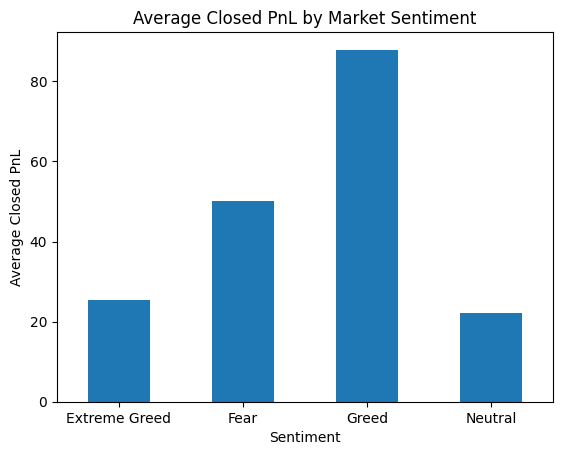

In [89]:
import matplotlib.pyplot as plt

avg_PnL.plot(kind = 'bar')

plt.title("Average Closed PnL by Market Sentiment")
plt.xlabel('Sentiment')
plt.ylabel('Average Closed PnL')
plt.xticks(rotation = 0)

plt.show()

## Insight 1:

Greed days deliver the highest average PnL — but with smaller position sizes. 
Average Closed PnL is highest during Greed (87) and lowest during Neutral 
(22) and Extreme Greed (25), with Fear in between (50). Notably, this 
isn't driven by traders sizing up — average trade size during Greed (~3,183) 
is actually the smallest of all four regimes. This suggests Greed-day 
profitability comes from better trade selection/timing, not bigger bets.

In [90]:
traders_by_sentiment = df_merged.groupby('classification').size()
traders_by_sentiment

classification
Extreme Greed      6962
Fear             133871
Greed             36289
Neutral            7141
dtype: int64

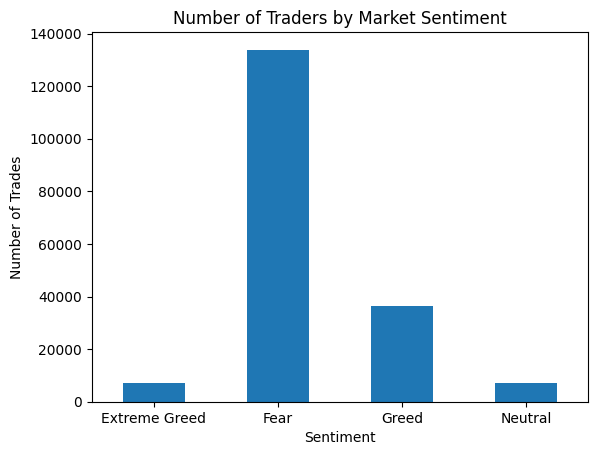

In [91]:
traders_by_sentiment.plot(kind = 'bar')

plt.title("Number of Traders by Market Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Number of Trades")
plt.xticks(rotation = 0)

plt.show()

## Insight 2:

Fear dominates trading activity, accounting for ~73% of all trades. 
Of ~184,000 total trades in the dataset, Fear days alone account for 
133,871 (~73%), far exceeding Greed (36,289), Neutral (7,141), and 
Extreme Greed (6,962). Despite this heavy activity, average PnL during 
Fear (50) is still well below Greed (87) — traders are most active 
exactly when average returns are lower, pointing to reactive trading 
rather than opportunistic trading.

In [93]:
Avg_trade_size = df_merged.groupby('classification')['Size USD'].mean()
Avg_trade_size

classification
Extreme Greed    5660.265764
Fear             5259.977837
Greed            3182.883845
Neutral          3058.848110
Name: Size USD, dtype: float64

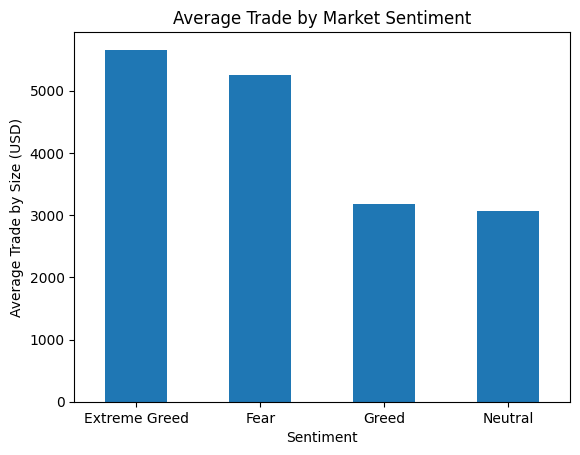

In [94]:
Avg_trade_size.plot(kind = 'bar')
plt.title("Average Trade by Market Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average Trade by Size (USD)")
plt.xticks(rotation = 0)

plt.show()

In [96]:
buy_sell = pd.crosstab(
    df_merged['classification'],
    df_merged['Side']
)

buy_sell

Side,BUY,SELL
classification,,
Extreme Greed,3371,3591
Fear,66081,67790
Greed,15421,20868
Neutral,3505,3636


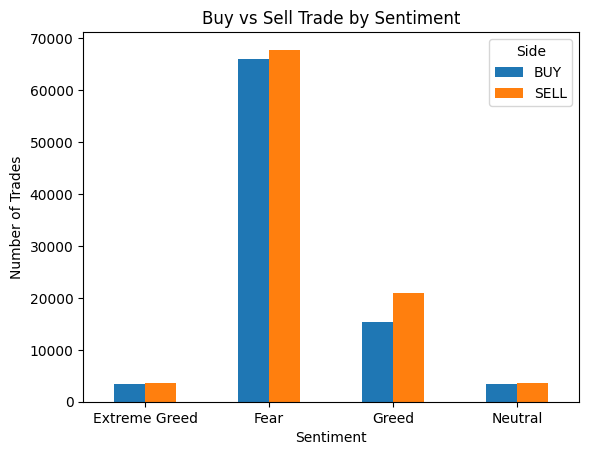

In [98]:
buy_sell.plot(kind = 'bar')

plt.title("Buy vs Sell Trade by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel('Number of Trades')
plt.xticks(rotation = 0)

plt.show()

## Insight 3:

Traders size up during Fear and Extreme Greed, not during Greed or Neutral. 
Average trade size is highest during Extreme Greed (~5,660) and Fear 
(~5,260), but drops sharply during Greed (~3,183) and Neutral (~3,059). 
Combined with the buy/sell split — Greed shows a 57.5% sell skew versus a 
near-balanced ~50/50 split on Fear, Neutral, and Extreme Greed days — this 
suggests traders take larger, more decisive positions at sentiment extremes 
while trading smaller and more defensively (net-selling) during plain Greed.

In [100]:
df_merged.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'Date', 'timestamp', 'value', 'classification', 'date'],
      dtype='object')

In [103]:
trade_counts = df_merged['Account'].value_counts()
trade_counts

Account
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    40184
0xbaaaf6571ab7d571043ff1e313a9609a10637864    21192
0xa0feb3725a9335f49874d7cd8eaad6be45b27416    15605
0x8477e447846c758f5a675856001ea72298fd9cb5    14998
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    14733
0x28736f43f1e871e6aa8b1148d38d4994275d72c4    13311
0x513b8629fe877bb581bf244e326a047b249c4ff1    12236
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4     9893
0x47add9a56df66b524d5e2c1993a43cde53b6ed85     8519
0x4f93fead39b70a1824f981a54d4e55b278e9f760     7584
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd     7280
0xb899e522b5715391ae1d4f137653e7906c5e2115     4838
0x8170715b3b381dffb7062c0298972d4727a0a63b     4601
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4     4356
0x083384f897ee0f19899168e3b1bec365f52a9012     3818
0x271b280974205ca63b716753467d5a371de622ab     3809
0x39cef799f8b69da1995852eea189df24eb5cae3c     3589
0x2c229d22b100a7beb69122eed721cee9b24011dd     3239
0x92f17e8d81a944691c10e753af1b1baae1a2cd0d     3052
0xbd

In [105]:
median_trades = trade_counts.median()
median_trades

np.float64(3699.0)

In [114]:
frequent_traders = trade_counts[trade_counts > median_trades]
infrequent_traders = trade_counts[trade_counts <= median_trades]

print('Frequent Traders:', frequent_traders)
print('Inrequent Traders:', infrequent_traders)

Frequent Traders: Account
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    40184
0xbaaaf6571ab7d571043ff1e313a9609a10637864    21192
0xa0feb3725a9335f49874d7cd8eaad6be45b27416    15605
0x8477e447846c758f5a675856001ea72298fd9cb5    14998
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    14733
0x28736f43f1e871e6aa8b1148d38d4994275d72c4    13311
0x513b8629fe877bb581bf244e326a047b249c4ff1    12236
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4     9893
0x47add9a56df66b524d5e2c1993a43cde53b6ed85     8519
0x4f93fead39b70a1824f981a54d4e55b278e9f760     7584
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd     7280
0xb899e522b5715391ae1d4f137653e7906c5e2115     4838
0x8170715b3b381dffb7062c0298972d4727a0a63b     4601
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4     4356
0x083384f897ee0f19899168e3b1bec365f52a9012     3818
0x271b280974205ca63b716753467d5a371de622ab     3809
Name: count, dtype: int64
Inrequent Traders: Account
0x39cef799f8b69da1995852eea189df24eb5cae3c    3589
0x2c229d22b100a7beb69122eed721cee9b240

In [115]:
trader_PnL = df_merged.groupby('Account')['Closed PnL'].mean()
trader_PnL

print("Consistent winners vs Inconsistent Winners")
consistent_winners = trader_PnL[trader_PnL > 0]
inconsistent_winners = trader_PnL[trader_PnL <= 0]

print('Consistent Winners:', consistent_winners)
print('Inconsistent Winners:', inconsistent_winners)

Consistent winners vs Inconsistent Winners
Consistent Winners: Account
0x083384f897ee0f19899168e3b1bec365f52a9012    419.127768
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd      6.577654
0x28736f43f1e871e6aa8b1148d38d4994275d72c4      9.951530
0x2c229d22b100a7beb69122eed721cee9b24011dd     52.071011
0x39cef799f8b69da1995852eea189df24eb5cae3c      4.028119
0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6    161.133275
0x420ab45e0bd8863569a5efbb9c05d91f40624641    520.902331
0x430f09841d65beb3f27765503d0f850b8bce7713    336.735548
0x47add9a56df66b524d5e2c1993a43cde53b6ed85     12.130968
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    155.589314
0x4f93fead39b70a1824f981a54d4e55b278e9f760     40.740489
0x513b8629fe877bb581bf244e326a047b249c4ff1     68.684419
0x6d6a4b953f202f8df5bed40692e7fd865318264a    111.519197
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    270.034947
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    281.826227
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4     38.319560
0x7f4f299f74eec87

# Part C - Strategy Recommendations

## Strategy 1: Scale exposure selectively during Greed — gated by trader consistency
Grouping average Closed PnL by account (df_merged.groupby('Account')['Closed PnL].mean()) shows a clear split between consistent winners (mean Closed PnL > 0) and inconsistent traders (mean Closed PnL ≤ 0). Since inconsistent traders lose on average regardless of overall market sentiment, their underperformance is behavior-driven rather than market-driven.
Rule: During Greed days, increase exposure only for accounts with a historically positive average Closed PnL. Accounts with average Closed PnL ≤ 0 should keep position size flat regardless of sentiment.

## Strategy 2: Cut position size during Fear — especially for high Size USD traders
Fear days show more volatile and lower average outcomes. This effect is amplified for traders with high average Size USD, since larger positions compound losses faster during uncertain market conditions.
Rule: On Fear days, high-Size-USD traders should reduce position size by ~30–50% and avoid new entries. Traders with smaller average Size USD can maintain normal activity, since their drawdown exposure is inherently smaller.

## Strategy 3: Treat Greed-day sell-side skew as a crowding signal, not a bullish one
Buy/sell activity is fairly balanced during Fear (49.4%/50.6%) and Neutral (49.1%/50.9%) days, but Greed days show a clear skew toward selling (57.5% sell vs. 42.5% buy) — the opposite of what "greed" intuitively implies.
Rule: Don't treat Greed sentiment as a default signal to add long exposure. Monitor the sell-side skew as an early warning of profit-taking, and size new entries more conservatively when the sell ratio exceeds ~55%.